Сценарій 3. Аналітика показала значний відтік користувачів на етапі оформлення замовлення. Команда вирішила протестувати спрощений процес checkout.
Ось базові вхідні дані для планування:
* **Базова конверсія (Baseline CR):** 15.65%
Охоплення - 59765 користувачів
Submited checkout  - 9354
* **Середній щоденний трафік:** 2000 користувачів
* **Первинна метрика:** `purchase_conversion_rate` (конверсія в покупку)
* **Вторинні метрики:** `revenue` (виручка), `AOV` (середній чек)

H₀: Спрощена форма checkout не впливає на конверсію в покупку (CR однакова в групах A і B).
H₁: Спрощена форма checkout впливає на конверсію в покупку (CR відрізняється між групами A і B).
Гіпотеза двостороння
Для оцінки первинної метрики (CR) використовую Chi-Square Test, оскільки порівнюються частки успішних покупок між двома незалежними групами.
Для оцінки вторинної метрики Revenue використовую Welch's t-test, оскільки виручка є безперервною метрикою і може мати різну дисперсію між групами.
MDE - 5%


Розраховуємо розмір вибірки

In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_cr = 0.1565
mde_relative = 0.05

p1 = baseline_cr
p2 = baseline_cr * (1 + mde_relative)

alpha = 0.05
power = 0.80
ratio = 1  # 50/50 split

effect_size = proportion_effectsize(p1, p2)               #Перетворити дві конверсії на стандартизований розмір ефекту (Cohen's h), який потрібен для розрахунку вибірки.

analysis = NormalIndPower()                               #Створює об'єкт із методами для розрахунку потужності статистичних тестів та необхідного розміру вибірки.
sample_size_per_group = analysis.solve_power(             #розраховує відсутній параметр тесту на основі заданих параметрів
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=ratio,
    alternative='two-sided'
)

sample_size_per_group

34523.38349780304

In [ ]:
import math

n_per_group = math.ceil(sample_size_per_group)
total_sample = n_per_group * 2
Duration = total_sample / 2000

print(f"Baseline CR: {p1:.4%}")
print(f"Expected CR B: {p2:.4%}")
print(f"Sample size per group: {n_per_group}")
print(f"Total sample size: {total_sample}")
print(f"Duration: {Duration}")

Baseline CR: 15.6500%
Expected CR B: 16.4325%
Sample size per group: 34524
Total sample size: 69048
Duration: 34.524


Розрахункові параметри для тесту - розмір вибірки - 69048 користувачів, розмір вибірки на групу - 34524 користувачі, тривалість тесту - 35 днів (з округленням до більшого цілого)

Після проведення симуляції, отримали датасет

In [ ]:
import pandas as pd

df = pd.read_csv('stepup_ab_dataset_scenario_3.csv')
df

,user_id,group,converted,revenue,session_duration_sec,pages_viewed,clicks,device_type,traffic_source,date
0,usr_a_10000,A,0,0.00,119,3,17,Mobile,Email,2026-05-01
1,usr_a_10001,A,0,0.00,116,3,26,Mobile,Paid,2026-05-01
2,usr_a_10002,A,0,0.00,94,4,29,Mobile,Organic,2026-05-01
3,usr_a_10003,A,0,0.00,107,3,36,Mobile,Email,2026-05-01
4,usr_a_10004,A,0,0.00,115,7,19,Mobile,Paid,2026-05-01
...,...,...,...,...,...,...,...,...,...,...
69043,usr_b_79043,B,0,0.00,103,7,32,Mobile,Paid,2026-06-04
69044,usr_b_79044,B,0,0.00,119,8,16,Desktop,Email,2026-06-04
69045,usr_b_79045,B,0,0.00,90,6,34,Mobile,Paid,2026-06-04
69046,usr_b_79046,B,0,0.00,90,5,34,Mobile,Paid,2026-06-04


In [ ]:
df.shape  #перевірка розміру

(69048, 10)

In [ ]:
df['date'].nunique()  #перевірка тривалості

35

In [ ]:
group_stat = df.groupby('group')['converted'].agg(       #перевірка конверсій в групах
    users = 'count',
    conversions = 'sum',
    conversion_rate = 'mean'
)
group_stat

,users,conversions,conversion_rate
group,,,
A,34524,5454,0.157977
B,34524,5598,0.162148


In [ ]:
revenue_stat = df.groupby('group')['revenue'].agg(                 #перевірка доходу в групах в групах
    users = 'count',
    total_revenue='sum',
    ARPU='mean'
)
revenue_stat

,users,total_revenue,ARPU
group,,,
A,34524,245911.10,7.122903
B,34524,252572.24,7.315845


In [ ]:
((df['converted'] == 0) & (df['revenue'] > 0)).sum()    #перевірка наявності доходу при відсутності покупки

np.int64(0)

In [ ]:
((df['converted'] == 1) & (df['revenue'] == 0)).sum()       #перевірка відсутності доходу при здійсненні покупки

np.int64(0)

In [ ]:
df.isna().sum()               #перевірка відсутніх значень

,0
user_id,0
group,0
converted,0
revenue,0
session_duration_sec,0
pages_viewed,0
clicks,0
device_type,0
traffic_source,0
date,0


In [ ]:
pd.crosstab(df['group'], df['device_type'])        #перевірка розподілу користувачів за типами пристроїв

device_type,Desktop,Mobile
group,,
A,8681,25843
B,8629,25895


In [ ]:
pd.crosstab(df['group'], df['traffic_source'])          #перевірка розподілу користувачів за джерелами трафіку

traffic_source,Email,Organic,Paid
group,,,
A,6545,15605,12374
B,6521,15631,12372


In [ ]:
uplift_conv = (                                           #фактичний відносний приріст конверсії між групами
    df[df.group=='B']['converted'].mean()
    /
    df[df.group=='A']['converted'].mean()
    - 1
)

print(f"{uplift_conv:.2%}")

2.64%


In [ ]:
uplift_rev= (                                           #фактичний відносний приріст доходу між групами
    df[df.group=='B']['revenue'].mean()
    /
    df[df.group=='A']['revenue'].mean()
    - 1
)

print(f"{uplift_rev:.2%}")

2.71%


In [ ]:
df[df['converted']==1].groupby('group')['revenue'].value_counts()

group  revenue
A      39.21      8
       46.54      8
       56.35      8
       59.60      8
       34.07      7
                 ..
B      59.90      1
       59.93      1
       59.94      1
       59.96      1
       60.00      1
Name: count, Length: 5024, dtype: int64

In [ ]:
buyers = df[df["converted"] == 1]                  #оцінка середнього чеку в групах

buyers.groupby("group")["revenue"].agg(
    purchases="count",
    mean_check="mean",
    median_check="median",
    std_check="std"
)

,purchases,mean_check,median_check,std_check
group,,,,
A,5454,45.088210,45.220,8.623327
B,5598,45.118299,45.205,8.636272


In [ ]:
buyers.groupby(                                       #оцінка середнього чеку в групах в розрізі пристроїв
    ["group", "device_type"]
)["revenue"].agg(
    purchases="count",
    arppu="mean",
    median_check="median"
)

purchases      arppu  median_check
group device_type                                    
A     Desktop           1403  45.376736        45.790
      Mobile            4051  44.988284        45.150
B     Desktop            778  45.003239        45.635
      Mobile            4820  45.136871        45.160

In [ ]:
df.groupby(["group", "device_type"])["converted"].mean()           #оцінка значень конверсії по групах в розрізі пристроїв

group  device_type
A      Desktop        0.161617
       Mobile         0.156754
B      Desktop        0.090161
       Mobile         0.186136
Name: converted, dtype: float64

Виявлено суттєві відмінності між сегментами Desktop та Mobile. Для перевірки статистичної значущості ефекту доцільно провести окремий аналіз для кожного типу пристрою.


In [ ]:
df.groupby(["group", "device_type"])["revenue"].mean()

group  device_type
A      Desktop        7.333667
       Mobile         7.052105
B      Desktop        4.057541
       Mobile         8.401611
Name: revenue, dtype: float64

Виявлено суттєві відмінності в середньому доході  між сегментами Desktop та Mobile. Для перевірки статистичної значущості ефекту доцільно провести окремий аналіз для кожного типу пристрою.


Для перевірки гіпотези про вплив нового checkout на конверсію проведемо χ²-тест незалежності.

In [ ]:
converted = pd.crosstab(df['group'], df['converted'])
converted

converted,0,1
group,,
A,29070,5454
B,28926,5598


In [ ]:
from scipy.stats import chi2_contingency

contingency_table = [
    [converted.loc['A', 1], converted.loc['A', 0]],  # Group A
    [converted.loc['B', 1], converted.loc['B', 0]]   # Group B
]

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p_value)
if p_value < 0.05:
    print("Відхиляємо H0")
else:
    print("Не відхиляємо H0")

Chi-square: 2.202846630105682
p-value: 0.1377561387309539
Не відхиляємо H0


Chi-square тест не виявив статистично значущих відмінностей між групами (p-value = 0.138 > 0.05). На рівні всієї аудиторії немає достатніх підстав відхиляти нульову гіпотезу про відсутність впливу нового checkout на конверсію.

Додаткова перевірка за допомогою z-test

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

count = [converted.loc['A', 1], converted.loc['B', 1]]
nobs = [group_stat.loc['A', 'users'], group_stat.loc['B', 'users']]

z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative='two-sided'
)

print(z_stat)
print(p_value)

-1.4945779999092288
0.13502461131394136


Для перевірки гіпотези про вплив нового checkout на дохід проведемо Welch's t-test.

In [ ]:
from scipy.stats import ttest_ind

revenue_A = df[df['group'] == 'A']['revenue']
revenue_B = df[df['group'] == 'B']['revenue']

t_stat, p_value = ttest_ind(
    revenue_A,
    revenue_B,
    equal_var=False  # Welch's t-test
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Відхиляємо H0")
else:
    print("Не відхиляємо H0")

t-statistic: -1.500490449651856
p-value: 0.13349197862144782
Не відхиляємо H0


Welch's t-test не виявив статистично значущої різниці доходу між групами (p-value = 0.133 > 0.05). На рівні всієї аудиторії немає підстав стверджувати, що нова форма checkout вплинула на дохід.

Оскільки загальний аналіз не виявив статистично значущих змін, перевіримо результати окремо для Desktop та Mobile користувачів. Це дозволить виявити можливі відмінності між сегментами, які можуть бути приховані в агрегованих даних.

In [ ]:
df.groupby('group')['revenue'].agg(
    users='count',
    mean='mean',
    median='median',
    std='std'
)

,users,mean,median,std
group,,,,
A,34524,7.122903,0.0,16.798115
B,34524,7.315845,0.0,16.989907


In [ ]:
segment_conv = df.groupby(['group', 'device_type'])['converted'].agg(
    users='count',
    conversions='sum',
    cr='mean'
)
segment_conv

users  conversions        cr
group device_type                              
A     Desktop       8681         1403  0.161617
      Mobile       25843         4051  0.156754
B     Desktop       8629          778  0.090161
      Mobile       25895         4820  0.186136

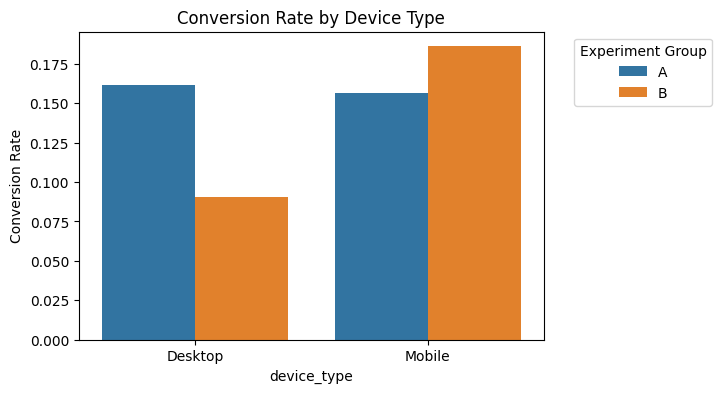

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))

sns.barplot(
    data=segment_conv,
    x='device_type',
    y='cr',
    hue='group'
)
plt.legend(
    title='Experiment Group',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Conversion Rate by Device Type')
plt.ylabel('Conversion Rate')
plt.show()

Попередній аналіз показав, що конверсія в групі B зросла для Mobile-користувачів та знизилася для Desktop-користувачів. Для перевірки, чи є ці відмінності статистично значущими, проведено χ²-тест окремо для кожного сегмента.

In [ ]:
mobile = df[df['device_type'] == 'Mobile']
mobile_converted = pd.crosstab(mobile['group'], mobile['converted'])
mobile_converted

converted,0,1
group,,
A,21792,4051
B,21075,4820


In [ ]:
desktop = df[df['device_type'] == 'Desktop']
desktop_converted =pd.crosstab(desktop['group'], desktop['converted'])
desktop_converted

converted,0,1
group,,
A,7278,1403
B,7851,778


In [ ]:
mob_contingency_table = [
    [mobile_converted.loc['A', 1], mobile_converted.loc['A', 0]],  # Group A
    [mobile_converted.loc['B', 1], mobile_converted.loc['B', 0]]   # Group B
]

mob_chi2, mob_p_value, mob_dof, mob_expected = chi2_contingency(mob_contingency_table)

print("Chi-square:", mob_chi2)
print("p-value:", mob_p_value)
if mob_p_value < 0.05:
    print("Відхиляємо H0")
else:
    print("Не відхиляємо H0")

Chi-square: 78.39604770827307
p-value: 8.43207028862998e-19
Відхиляємо H0


χ²-тест показав статистично значуще зростання конверсії серед Mobile-користувачів (p-value < 0.05). Це свідчить про позитивний вплив нового checkout на даний сегмент аудиторії.

In [ ]:
desktop_contingency_table = [
    [desktop_converted.loc['A', 1], desktop_converted.loc['A', 0]],  # Group A
    [desktop_converted.loc['B', 1], desktop_converted.loc['B', 0]]   # Group B
]

desktop_chi2, desktop_p_value, desktop_dof, desktop_expected = chi2_contingency(desktop_contingency_table)

print("Chi-square:", desktop_chi2)
print("p-value:", desktop_p_value)
if desktop_p_value < 0.05:
    print("Відхиляємо H0")
else:
    print("Не відхиляємо H0")

Chi-square: 200.0028243573366
p-value: 2.085525765730941e-45
Відхиляємо H0


χ²-тест показав статистично значуще зниження конверсії серед Desktop-користувачів (p-value < 0.05). Це свідчить про негативний вплив нового checkout на даний сегмент аудиторії.

Результати сегментного аналізу показали протилежний вплив нового checkout на різні типи пристроїв. Саме цим пояснюється відсутність статистично значущого ефекту на рівні всієї аудиторії.

In [ ]:
df.groupby(['group', 'device_type'])['revenue'].agg(
    users='count',
    mean='mean',
    median='median',
    std='std'
)

users      mean  median        std
group device_type                                    
A     Desktop       8681  7.333667     0.0  17.072406
      Mobile       25843  7.052105     0.0  16.704704
B     Desktop       8629  4.057541     0.0  13.154742
      Mobile       25895  8.401611     0.0  17.957532

In [ ]:
from scipy.stats import ttest_ind

mobile = df[df['device_type'] == 'Mobile']

mobile_rev_A = mobile[mobile['group'] == 'A']['revenue']
mobile_rev_B = mobile[mobile['group'] == 'B']['revenue']

t_stat, p_value = ttest_ind(
    mobile_rev_A,
    mobile_rev_B,
    equal_var=False
)

print(t_stat)
print(p_value)
if p_value < 0.05:
    print("Відхиляємо H0")
else:
    print("Не відхиляємо H0")

-8.8502444217107
9.003395896385689e-19
Відхиляємо H0


Welch's t-test виявив статистично значущу різницю доходу між групами в сегменті Mobile-користувачів (p-value < 0.05).

In [ ]:
desktop = df[df['device_type'] == 'Desktop']

desktop_rev_A = desktop[desktop['group'] == 'A']['revenue']
desktop_rev_B = desktop[desktop['group'] == 'B']['revenue']

t_stat, p_value = ttest_ind(
    desktop_rev_A,
    desktop_rev_B,
    equal_var=False
)

print(t_stat)
print(p_value)
if p_value < 0.05:
    print("Відхиляємо H0")
else:
    print("Не відхиляємо H0")

14.146824516159064
3.6158662599981016e-45
Відхиляємо H0


У сегменті Desktop-користувачів було виявлено статистично значуще зниження доходу (p-value < 0.05).

Результати сегментного аналізу доходу підтверджують висновки, отримані для конверсії: новий checkout позитивно вплинув на Mobile-користувачів та негативно — на Desktop-користувачів.

In [ ]:
desktop_uplift = (
    segment_rev.loc[
        (segment_rev['group']=='B') &
        (segment_rev['device_type']=='Desktop'),
        'mean'
    ].iloc[0]
    /
    segment_rev.loc[
        (segment_rev['group']=='A') &
        (segment_rev['device_type']=='Desktop'),
        'mean'
    ].iloc[0]
    - 1
)

mobile_uplift = (
    segment_rev.loc[
        (segment_rev['group']=='B') &
        (segment_rev['device_type']=='Mobile'),
        'mean'
    ].iloc[0]
    /
    segment_rev.loc[
        (segment_rev['group']=='A') &
        (segment_rev['device_type']=='Mobile'),
        'mean'
    ].iloc[0]
    - 1
)

print(f"Desktop revenue uplift: {desktop_uplift:.2%}")
print(f"Mobile revenue uplift: {mobile_uplift:.2%}")

Desktop revenue uplift: -44.67%
Mobile revenue uplift: 19.14%


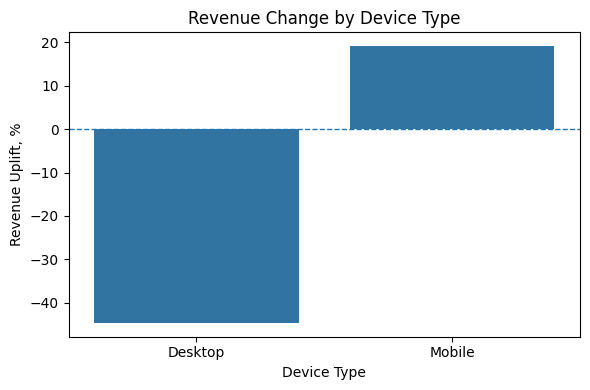

In [ ]:
uplift_df = pd.DataFrame({
    'device_type': ['Desktop', 'Mobile'],
    'revenue_uplift_pct': [desktop_uplift * 100, mobile_uplift * 100]
})

plt.figure(figsize=(6, 4))

sns.barplot(
    data=uplift_df,
    x='device_type',
    y='revenue_uplift_pct'
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title('Revenue Change by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Revenue Uplift, %')

plt.tight_layout()
plt.show()

Аналіз показав протилежний ефект залежно від типу пристрою: дохід Desktop-користувачів знизився на 44,67%, тоді як дохід Mobile-користувачів зріс на 19,14%.

**Висновки**

На рівні всієї аудиторії спрощений checkout не продемонстрував статистично значущого впливу ні на конверсію, ні на дохід.

Подальший сегментний аналіз виявив суттєво різний вплив змін залежно від типу пристрою. Для мобільних користувачів спостерігається статистично значуще зростання конверсії та доходу, тоді як для Desktop-користувачів — статистично значуще погіршення обох метрик.

 Аналіз ARPPU не виявив суттєвих відмінностей між групами. Це свідчить про те, що зміни в доході були зумовлені насамперед зміною конверсії, а не середнього розміру покупки.

 Перед повним запуском змін рекомендується провести окреме дослідження Desktop-версії checkout для виявлення причин погіршення конверсії та доходу.